In [75]:
import pandas as pd
import numpy as np
from sklearn.preprocessing  import StandardScaler,MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [7]:
df = pd.read_csv("car_price_dataset.csv", sep=";")

In [8]:
df.head(6)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
5,Toyota,Camry,2007,2.7,Petrol,Automatic,157889,4,4,7242


In [ ]:
# check  there is null value or not 
print(df.isnull().sum())

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64


In [15]:
print(df["Brand"].value_counts())

print(df["Fuel_Type"].value_counts())



Brand
Ford          1048
Audi          1038
Volkswagen    1020
Honda         1009
Chevrolet     1003
BMW            999
Hyundai        995
Kia            976
Toyota         970
Mercedes       942
Name: count, dtype: int64
Fuel_Type
Electric    2625
Diesel      2512
Hybrid      2453
Petrol      2410
Name: count, dtype: int64


In [16]:
print(df["Transmission"].value_counts())

Transmission
Manual            3372
Automatic         3317
Semi-Automatic    3311
Name: count, dtype: int64


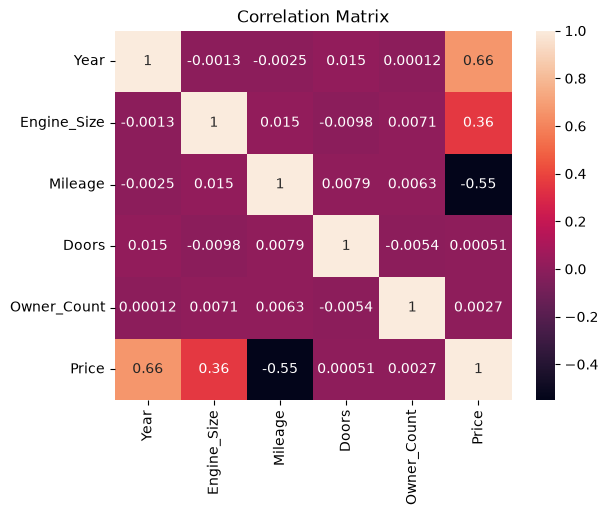

In [21]:
correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True)

plt.title("Correlation Matrix")
plt.show()

In [22]:
df_1 = pd.get_dummies(df,columns=["Brand", "Model","Transmission","Fuel_Type"],dtype=int)

In [27]:
df1=print(df_1.head(6))

   Year  Engine_Size  Mileage  Doors  Owner_Count  Price  Brand_Audi  \
0  2020          4.2   289944      3            5   8501           0   
1  2012          2.0     5356      2            3  12092           0   
2  2020          4.2   231440      4            2  11171           0   
3  2023          2.0   160971      2            1  11780           1   
4  2003          2.6   286618      3            3   2867           0   
5  2007          2.7   157889      4            4   7242           0   

   Brand_BMW  Brand_Chevrolet  Brand_Ford  ...  Model_Tiguan  Model_Tucson  \
0          0                0           0  ...             0             0   
1          0                1           0  ...             0             0   
2          0                0           0  ...             0             0   
3          0                0           0  ...             0             0   
4          0                0           0  ...             0             0   
5          0               

In [29]:
x = df_1.drop("Price", axis=1)
y = df_1["Price"]

In [31]:
print("Antal dimensioner:", x.shape[1])

print("Features:", x.columns.tolist())
print("Target: ", y.name)

Antal dimensioner: 52
Features: ['Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Brand_Audi', 'Brand_BMW', 'Brand_Chevrolet', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Kia', 'Brand_Mercedes', 'Brand_Toyota', 'Brand_Volkswagen', 'Model_3 Series', 'Model_5 Series', 'Model_A3', 'Model_A4', 'Model_Accord', 'Model_C-Class', 'Model_CR-V', 'Model_Camry', 'Model_Civic', 'Model_Corolla', 'Model_E-Class', 'Model_Elantra', 'Model_Equinox', 'Model_Explorer', 'Model_Fiesta', 'Model_Focus', 'Model_GLA', 'Model_Golf', 'Model_Impala', 'Model_Malibu', 'Model_Optima', 'Model_Passat', 'Model_Q5', 'Model_RAV4', 'Model_Rio', 'Model_Sonata', 'Model_Sportage', 'Model_Tiguan', 'Model_Tucson', 'Model_X5', 'Transmission_Automatic', 'Transmission_Manual', 'Transmission_Semi-Automatic', 'Fuel_Type_Diesel', 'Fuel_Type_Electric', 'Fuel_Type_Hybrid', 'Fuel_Type_Petrol']
Target:  Price


In [35]:
scalar = StandardScaler()
x_scale = scalar.fit_transform(x)

In [37]:
print(x_scale)


[[ 1.22602090e+00  1.04365690e+00  1.63007524e+00 ... -5.96600539e-01
  -5.70113860e-01 -5.63491843e-01]
 [ 6.61558054e-02 -8.70607405e-01 -1.66689517e+00 ... -5.96600539e-01
   1.75403559e+00 -5.63491843e-01]
 [ 1.22602090e+00  1.04365690e+00  9.52302614e-01 ... -5.96600539e-01
  -5.70113860e-01 -5.63491843e-01]
 ...
 [-2.23810469e-01 -4.87267277e-04 -7.24936723e-01 ... -5.96600539e-01
  -5.70113860e-01  1.77464858e+00]
 [-1.38367556e+00 -1.39267949e+00  8.86638467e-01 ... -5.96600539e-01
   1.75403559e+00 -5.63491843e-01]
 [-1.52865870e+00 -7.83595391e-01  1.00128420e-01 ... -5.96600539e-01
  -5.70113860e-01 -5.63491843e-01]]


In [38]:
#pca
pcs = PCA()
x_pca = pcs.fit_transform(x_scale)

In [40]:
print(x_pca)
print(x_pca.shape)

[[ 1.07676805e+00  9.42912574e-01 -1.38406559e+00 ...  1.74171139e-15
  -3.49238537e-16 -1.78449825e-15]
 [-1.14013677e-01  1.37488086e+00 -1.40398041e+00 ... -1.22466575e-15
  -1.37286091e-15  3.24815140e-15]
 [-4.37591922e-02  1.56540286e-01 -5.25249798e-01 ... -3.12201201e-16
  -1.06377250e-16 -9.72647661e-16]
 ...
 [-1.72514999e+00 -2.79547267e+00  1.01893153e+00 ... -4.04389172e-16
  -1.51648118e-15  3.71987680e-16]
 [ 3.53330465e+00 -8.00624471e-01  1.68418328e+00 ... -7.80576539e-16
   5.70029380e-16 -1.51192982e-15]
 [-1.48692160e+00 -1.02359889e+00  1.15977555e+00 ...  6.59243946e-16
  -1.18190581e-15  1.24779839e-15]]
(10000, 52)


In [41]:
pca1 =PCA(n_components =10)
x_pca_new = pca1.fit_transform(x_scale)
print(x_pca_new)
print(x_pca_new.shape)

[[ 1.07676805  0.94291257 -1.38406559 ... -2.07420929 -1.98583415
   1.27418943]
 [-0.11401368  1.37488086 -1.40398041 ...  1.62589685 -0.46745261
  -0.43689007]
 [-0.04375919  0.15654029 -0.5252498  ... -1.07029215  4.1627573
  -0.58500475]
 ...
 [-1.72514999 -2.79547267  1.01893153 ... -0.71452421 -0.65615673
  -0.22618794]
 [ 3.53330465 -0.80062447  1.68418328 ... -0.18161076 -0.06716033
  -0.42197104]
 [-1.4869216  -1.02359889  1.15977555 ...  0.01855436 -0.44955947
   1.72115507]]
(10000, 10)


In [47]:
x_full_train, x_test, y_train_full, y_test = train_test_split(x_pca_new,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(x_full_train, y_train_full, test_size=0.3, random_state=36)

In [64]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_val)

In [59]:
tree_clf = DecisionTreeRegressor()

# Finding the best hyperparameter through GridSearch.
hyper_params = {'max_depth':(None, 1, 2, 5, 10)}
clf = GridSearchCV(tree_clf, hyper_params)

clf.fit(X_train, y_train)
clf_pred = clf.predict(X_val)

In [60]:
from sklearn.ensemble import RandomForestRegressor

rf_clf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_clf,
    rf_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, 

In [61]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [65]:
# Predictions (already fit above) ---
lin_reg_pred = lin_reg.predict(X_val)
clf_pred = clf.predict(X_val)          # GridSearchCV automatically uses best_estimator_
rf_pred = rf_grid.predict(X_val)

In [70]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": rmse, "R2": r2}

results = [
    evaluate(y_val, lin_reg_pred, "Linear Regression"),
    evaluate(y_val, clf_pred, f"Decision Tree (best: {clf.best_params_})"),
    evaluate(y_val, rf_pred, f"Random Forest (best: {rf_grid.best_params_})"),
]


In [71]:
results_df = pd.DataFrame(results).sort_values("RMSE")
print(results_df.to_string(index=False))

best_model = results_df.iloc[0]
print(f"\nBest model: {best_model['Model']} (RMSE={best_model['RMSE']:.4f}, R2={best_model['R2']:.4f})")

                                                                                 Model        RMSE       R2
Random Forest (best: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}) 1403.676327 0.799933
                                             Decision Tree (best: {'max_depth': None}) 2145.823000 0.532448
                                                                     Linear Regression 3135.129294 0.001948

Best model: Random Forest (best: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}) (RMSE=1403.6763, R2=0.7999)


In [72]:
rf_final=rf_grid.fit(x_full_train, y_train_full)

In [73]:
rf_test_pred = rf_final.predict(x_test)

In [76]:
rf_rmse_test = root_mean_squared_error(rf_test_pred, y_test)
print(rf_rmse_test)

1294.0299661633903


In [78]:
from sklearn.metrics import root_mean_squared_error, r2_score
import joblib

# --- Test evaluation ---
rf_test_pred = rf_final.predict(x_test)

rf_rmse_test = root_mean_squared_error(y_test, rf_test_pred)   # note: (y_true, y_pred) order
rf_r2_test = r2_score(y_test, rf_test_pred)

print(f"Test RMSE: {rf_rmse_test:.4f}")
print(f"Test R2:   {rf_r2_test:.4f}")

# --- Save the final model with joblib ---
joblib.dump(rf_final, "rf_final_model.pkl")
print("Model saved to rf_final_model.pkl")

Test RMSE: 1294.0300
Test R2:   0.8177
Model saved to rf_final_model.pkl
